# Experiment B : Preliminary Feature Set

This experiment tests the preliminary feature set identified during the dataset exploration stage.

The same CCHS 2022 modelling population and train/validation/test approach used in the baseline experiment are retained so that the effect of changing the feature set can be examined.

In [1]:
import pandas as pd

In [3]:
pumf = pd.read_csv("pumf_cchs.csv")

print("PUMF shape:", pumf.shape)

PUMF shape: (67079, 255)


In [4]:
target_counts = pumf["CCC_05"].value_counts(dropna=False).sort_index()

print(target_counts)

CCC_05
1     5994
2    60248
9      837
Name: count, dtype: int64


In [5]:
model_data = pumf[pumf["CCC_05"].isin([1, 2])].copy()

model_data["target"] = (model_data["CCC_05"] == 1).astype(int)

print("Modelling population:", model_data.shape[0])
print(model_data["target"].value_counts().sort_index())

Modelling population: 66242
target
0    60248
1     5994
Name: count, dtype: int64


In [6]:
FEATURES = [
    "ALCDVTTM",
    "DHHDGHSZ",
    "DHHGAGE",
    "DHH_SEX",
    "EDDVH3",
    "FSCDVHF2",
    "GEOGPRV",
    "BMI_CLASS",
    "INCDGHH",
    "ECV_05",
    "SDCDGIMM"
]

print("Number of features:", len(FEATURES))
print("Features:")
print(FEATURES)

Number of features: 11
Features:
['ALCDVTTM', 'DHHDGHSZ', 'DHHGAGE', 'DHH_SEX', 'EDDVH3', 'FSCDVHF2', 'GEOGPRV', 'BMI_CLASS', 'INCDGHH', 'ECV_05', 'SDCDGIMM']


In [7]:
model_data["BMI_CLASS"] = np.nan

youth_mask = model_data["DHHGAGE"] == 1
adult_mask = model_data["DHHGAGE"].isin([2, 3, 4, 5])

model_data.loc[youth_mask, "BMI_CLASS"] = model_data.loc[youth_mask, "HWTDGWHO"]
model_data.loc[adult_mask, "BMI_CLASS"] = model_data.loc[adult_mask, "HWTDGISW"]

print("BMI_CLASS created.")
print(model_data[["DHHGAGE", "HWTDGWHO", "HWTDGISW", "BMI_CLASS"]].head(10))

NameError: name 'np' is not defined

In [8]:
import numpy as np

In [9]:
model_data["BMI_CLASS"] = np.nan

youth_mask = model_data["DHHGAGE"] == 1
adult_mask = model_data["DHHGAGE"].isin([2, 3, 4, 5])

model_data.loc[youth_mask, "BMI_CLASS"] = model_data.loc[youth_mask, "HWTDGWHO"]
model_data.loc[adult_mask, "BMI_CLASS"] = model_data.loc[adult_mask, "HWTDGISW"]

print("BMI_CLASS created.")
print(model_data[["DHHGAGE", "HWTDGWHO", "HWTDGISW", "BMI_CLASS"]].head(10))

BMI_CLASS created.
   DHHGAGE  HWTDGWHO  HWTDGISW  BMI_CLASS
0        5         6         1        1.0
1        4         6         2        2.0
2        1         1         6        1.0
3        2         6         1        1.0
4        3         6         1        1.0
5        5         6         2        2.0
6        3         6         2        2.0
7        5         6         2        2.0
8        2         6         2        2.0
9        3         6         2        2.0


In [10]:
print("BMI_CLASS by age group:")

print(
    pd.crosstab(
        model_data["DHHGAGE"],
        model_data["BMI_CLASS"],
        dropna=False
    )
)

BMI_CLASS by age group:
BMI_CLASS   1.0    2.0  6.0  9.0
DHHGAGE                         
1          2444    965    0  335
2          4861   4560   10  627
3          4487   7517    3  609
4          5257  10116    8  660
5          9004  13887   11  881


In [11]:
SPECIAL_CODES = {
    "ALCDVTTM": [9],
    "DHHDGHSZ": [9],
    "DHHGAGE": [],
    "DHH_SEX": [],
    "EDDVH3": [9],
    "FSCDVHF2": [9],
    "GEOGPRV": [],
    "INCDGHH": [9],
    "ECV_05": [9],
    "SDCDGIMM": [9],
    "HWTDGISW": [6, 9],
    "HWTDGWHO": [6, 9],
    "BMI_CLASS": [6, 9]
}

def apply_special_codes(df, special_codes):
    result = df.copy()

    for column, codes in special_codes.items():
        if column in result.columns:
            result[column] = result[column].replace(codes, np.nan)

    return result

clean_model_data = apply_special_codes(model_data, SPECIAL_CODES)

print("Special-value handling applied.")

Special-value handling applied.


In [12]:
print("BMI_CLASS values after special-value handling:")
print(clean_model_data["BMI_CLASS"].value_counts(dropna=False).sort_index())

print("\nMissing values in Experiment B features:")
print(clean_model_data[FEATURES].isna().sum())

BMI_CLASS values after special-value handling:
BMI_CLASS
1.0    26053
2.0    37045
NaN     3144
Name: count, dtype: int64

Missing values in Experiment B features:
ALCDVTTM      303
DHHDGHSZ      486
DHHGAGE         0
DHH_SEX         0
EDDVH3       2276
FSCDVHF2     1513
GEOGPRV         0
BMI_CLASS    3144
INCDGHH       947
ECV_05        141
SDCDGIMM      835
dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
RANDOM_STATE = 42

train_val_idx, test_idx = train_test_split(
    model_data.index,
    test_size=0.20,
    stratify=model_data["target"],
    random_state=RANDOM_STATE
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.20,
    stratify=model_data.loc[train_val_idx, "target"],
    random_state=RANDOM_STATE
)

print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nTarget prevalence:")
print(f"Training:   {model_data.loc[train_idx, 'target'].mean():.3%}")
print(f"Validation: {model_data.loc[val_idx, 'target'].mean():.3%}")
print(f"Test:       {model_data.loc[test_idx, 'target'].mean():.3%}")

Training: 42394
Validation: 10599
Test: 13249

Target prevalence:
Training:   9.048%
Validation: 9.048%
Test:       9.050%


In [15]:
X_train = clean_model_data.loc[train_idx, FEATURES]
X_val = clean_model_data.loc[val_idx, FEATURES]
X_test = clean_model_data.loc[test_idx, FEATURES]

y_train = model_data.loc[train_idx, "target"]
y_val = model_data.loc[val_idx, "target"]
y_test = model_data.loc[test_idx, "target"]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (42394, 11) (42394,)
Validation: (10599, 11) (10599,)
Test: (13249, 11) (13249,)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [17]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, FEATURES)
])

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (42394, 41)
Processed validation shape: (10599, 41)
Processed test shape: (13249, 41)


In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Model training completed.")

Model training completed.


In [22]:
train_prob = logistic_model.predict_proba(X_train_processed)[:, 1]
val_prob = logistic_model.predict_proba(X_val_processed)[:, 1]
test_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predicted probabilities generated.")

Predicted probabilities generated.


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

for name, y_true, prob in [
    ("Train", y_train, train_prob),
    ("Validation", y_val, val_prob),
    ("Test", y_test, test_prob)
]:
    pred = (prob >= 0.5).astype(int)

    print(f"\n{name}")
    print(f"Accuracy:  {accuracy_score(y_true, pred):.3f}")
    print(f"Precision: {precision_score(y_true, pred):.3f}")
    print(f"Recall:    {recall_score(y_true, pred):.3f}")
    print(f"F1:        {f1_score(y_true, pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, prob):.3f}")
    print(f"PR-AUC:    {average_precision_score(y_true, prob):.3f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, pred))


Train
Accuracy:  0.665
Precision: 0.187
Recall:    0.809
F1:        0.304
ROC-AUC:   0.794
PR-AUC:    0.239
Confusion matrix:
[[25096 13462]
 [  734  3102]]

Validation
Accuracy:  0.659
Precision: 0.184
Recall:    0.808
F1:        0.300
ROC-AUC:   0.794
PR-AUC:    0.256
Confusion matrix:
[[6214 3426]
 [ 184  775]]

Test
Accuracy:  0.659
Precision: 0.182
Recall:    0.791
F1:        0.296
ROC-AUC:   0.792
PR-AUC:    0.260
Confusion matrix:
[[7788 4262]
 [ 251  948]]


In [24]:
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    val_pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "accuracy": accuracy_score(y_val, val_pred)
    })

threshold_table = pd.DataFrame(threshold_results)

print(threshold_table.round(3).to_string(index=False))

 threshold  precision  recall    f1  accuracy
      0.10      0.112   0.991 0.202     0.292
      0.15      0.119   0.981 0.212     0.341
      0.20      0.129   0.972 0.227     0.402
      0.25      0.136   0.958 0.238     0.446
      0.30      0.144   0.943 0.250     0.487
      0.35      0.154   0.918 0.263     0.535
      0.40      0.164   0.895 0.277     0.577
      0.45      0.174   0.864 0.290     0.617
      0.50      0.184   0.808 0.300     0.659
      0.55      0.202   0.738 0.317     0.712
      0.60      0.215   0.641 0.322     0.756
      0.65      0.233   0.548 0.327     0.795
      0.70      0.249   0.444 0.319     0.828
      0.75      0.279   0.310 0.293     0.865
      0.80      0.325   0.169 0.222     0.893
      0.85      0.402   0.077 0.129     0.906
      0.90      0.667   0.010 0.021     0.910


In [25]:
fine_thresholds = np.arange(0.60, 0.701, 0.005)

fine_results = []

for threshold in fine_thresholds:
    val_pred = (val_prob >= threshold).astype(int)

    fine_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "accuracy": accuracy_score(y_val, val_pred)
    })

fine_threshold_table = pd.DataFrame(fine_results)

print(
    fine_threshold_table
    .round(4)
    .to_string(index=False)
)

 threshold  precision  recall     f1  accuracy
     0.600     0.2149  0.6413 0.3219    0.7555
     0.605     0.2171  0.6309 0.3230    0.7607
     0.610     0.2208  0.6225 0.3260    0.7671
     0.615     0.2208  0.6121 0.3246    0.7695
     0.620     0.2222  0.6006 0.3244    0.7737
     0.625     0.2252  0.5933 0.3264    0.7785
     0.630     0.2287  0.5881 0.3293    0.7833
     0.635     0.2306  0.5839 0.3307    0.7861
     0.640     0.2310  0.5777 0.3301    0.7878
     0.645     0.2309  0.5641 0.3277    0.7905
     0.650     0.2325  0.5485 0.3266    0.7954
     0.655     0.2333  0.5412 0.3260    0.7975
     0.660     0.2339  0.5328 0.3251    0.7998
     0.665     0.2334  0.5203 0.3222    0.8020
     0.670     0.2356  0.5151 0.3233    0.8049
     0.675     0.2395  0.5047 0.3248    0.8102
     0.680     0.2411  0.4932 0.3239    0.8137
     0.685     0.2403  0.4828 0.3209    0.8151
     0.690     0.2426  0.4713 0.3203    0.8190
     0.695     0.2449  0.4588 0.3193    0.8230
     0.700   

In [26]:
FINAL_THRESHOLD = 0.635

print(f"Final threshold locked at: {FINAL_THRESHOLD:.3f}")
print(
    fine_threshold_table.loc[
        fine_threshold_table["f1"].idxmax()
    ].round(4)
)

Final threshold locked at: 0.635
threshold    0.6350
precision    0.2306
recall       0.5839
f1           0.3307
accuracy     0.7861
Name: 7, dtype: float64


In [27]:
final_test_pred = (test_prob >= FINAL_THRESHOLD).astype(int)

print("Final Test Results")
print(f"Threshold: {FINAL_THRESHOLD:.3f}")
print(f"Accuracy:  {accuracy_score(y_test, final_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, final_test_pred):.3f}")
print(f"Recall:    {recall_score(y_test, final_test_pred):.3f}")
print(f"F1:        {f1_score(y_test, final_test_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, test_prob):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, test_prob):.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, final_test_pred))

Final Test Results
Threshold: 0.635
Accuracy:  0.786
Precision: 0.233
Recall:    0.598
F1:        0.336
ROC-AUC:   0.792
PR-AUC:    0.260

Confusion matrix:
[[9692 2358]
 [ 482  717]]


In [28]:
from sklearn.metrics import log_loss

train_log_loss = log_loss(y_train, train_prob)
val_log_loss = log_loss(y_val, val_prob)
test_log_loss = log_loss(y_test, test_prob)

print(f"Train Log Loss:       {train_log_loss:.6f}")
print(f"Validation Log Loss:  {val_log_loss:.6f}")
print(f"Test Log Loss:        {test_log_loss:.6f}")

Train Log Loss:       0.556745
Validation Log Loss:  0.561196
Test Log Loss:        0.556895


## Failure Analysis

In [29]:
test_results = X_test.copy()

test_results["actual"] = y_test.values
test_results["predicted"] = final_test_pred
test_results["probability"] = test_prob

test_results["error_type"] = "Correct"

test_results.loc[
    (test_results["actual"] == 1) & (test_results["predicted"] == 0),
    "error_type"
] = "False Negative"

test_results.loc[
    (test_results["actual"] == 0) & (test_results["predicted"] == 1),
    "error_type"
] = "False Positive"

print(test_results["error_type"].value_counts())

error_type
Correct           10409
False Positive     2358
False Negative      482
Name: count, dtype: int64


In [30]:
age_error_distribution = (
    test_results
    .groupby(["DHHGAGE", "error_type"])
    .size()
    .unstack(fill_value=0)
)

print(age_error_distribution)

error_type  Correct  False Negative  False Positive
DHHGAGE                                            
1               781               6               0
2              2005              26               0
3              2463              60               1
4              2514             178             416
5              2646             212            1941


In [31]:
sex_error_distribution = (
    test_results
    .groupby(["DHH_SEX", "error_type"])
    .size()
    .unstack(fill_value=0)
)

print(sex_error_distribution)

error_type  Correct  False Negative  False Positive
DHH_SEX                                            
1              4486             207            1496
2              5923             275             862


In [32]:
bmi_error_distribution = (
    test_results
    .groupby(["BMI_CLASS", "error_type"])
    .size()
    .unstack(fill_value=0)
)

print(bmi_error_distribution)

error_type  Correct  False Negative  False Positive
BMI_CLASS                                          
1.0            4905             208             181
2.0            5049             261            2054


In [33]:
bmi_error_rates = (
    test_results
    .groupby(["BMI_CLASS", "error_type"])
    .size()
    .unstack(fill_value=0)
)

bmi_error_rates["Total"] = bmi_error_rates.sum(axis=1)

for column in ["Correct", "False Negative", "False Positive"]:
    bmi_error_rates[f"{column} Rate"] = (
        bmi_error_rates[column] / bmi_error_rates["Total"]
    )

print(bmi_error_rates.round(3))

error_type  Correct  False Negative  False Positive  Total  Correct Rate  \
BMI_CLASS                                                                  
1.0            4905             208             181   5294         0.927   
2.0            5049             261            2054   7364         0.686   

error_type  False Negative Rate  False Positive Rate  
BMI_CLASS                                             
1.0                       0.039                0.034  
2.0                       0.035                0.279  


In [34]:
education_error_distribution = (
    test_results
    .groupby(["EDDVH3", "error_type"])
    .size()
    .unstack(fill_value=0)
)

print(education_error_distribution)

error_type  Correct  False Negative  False Positive
EDDVH3                                             
1.0             524              34             363
2.0            1609              91             605
3.0            7905             340            1324


In [35]:
education_error_rates = (
    test_results
    .groupby(["EDDVH3", "error_type"])
    .size()
    .unstack(fill_value=0)
)

education_error_rates["Total"] = education_error_rates.sum(axis=1)

for column in ["Correct", "False Negative", "False Positive"]:
    education_error_rates[f"{column} Rate"] = (
        education_error_rates[column] / education_error_rates["Total"]
    )

print(education_error_rates.round(3))

error_type  Correct  False Negative  False Positive  Total  Correct Rate  \
EDDVH3                                                                     
1.0             524              34             363    921         0.569   
2.0            1609              91             605   2305         0.698   
3.0            7905             340            1324   9569         0.826   

error_type  False Negative Rate  False Positive Rate  
EDDVH3                                                
1.0                       0.037                0.394  
2.0                       0.039                0.262  
3.0                       0.036                0.138  


In [36]:
income_error_distribution = (
    test_results
    .groupby(["INCDGHH", "error_type"])
    .size()
    .unstack(fill_value=0)
)

print(income_error_distribution)

error_type  Correct  False Negative  False Positive
INCDGHH                                            
1.0             317              13              84
2.0            1065              69             520
3.0            1378              71             473
4.0            1218              81             368
5.0            6276             237             894


In [37]:
income_error_rates = (
    test_results
    .groupby(["INCDGHH", "error_type"])
    .size()
    .unstack(fill_value=0)
)

income_error_rates["Total"] = income_error_rates.sum(axis=1)

for column in ["Correct", "False Negative", "False Positive"]:
    income_error_rates[f"{column} Rate"] = (
        income_error_rates[column] / income_error_rates["Total"]
    )

print(income_error_rates.round(3))

error_type  Correct  False Negative  False Positive  Total  Correct Rate  \
INCDGHH                                                                    
1.0             317              13              84    414         0.766   
2.0            1065              69             520   1654         0.644   
3.0            1378              71             473   1922         0.717   
4.0            1218              81             368   1667         0.731   
5.0            6276             237             894   7407         0.847   

error_type  False Negative Rate  False Positive Rate  
INCDGHH                                               
1.0                       0.031                0.203  
2.0                       0.042                0.314  
3.0                       0.037                0.246  
4.0                       0.049                0.221  
5.0                       0.032                0.121  


In [38]:
false_negatives = test_results[test_results["error_type"] == "False Negative"]
false_positives = test_results[test_results["error_type"] == "False Positive"]

print("False Negatives")
print(f"Count: {len(false_negatives)}")
print(f"Mean probability: {false_negatives['probability'].mean():.3f}")
print(f"Minimum probability: {false_negatives['probability'].min():.3f}")
print(f"Maximum probability: {false_negatives['probability'].max():.3f}")

print("\nFalse Positives")
print(f"Count: {len(false_positives)}")
print(f"Mean probability: {false_positives['probability'].mean():.3f}")
print(f"Minimum probability: {false_positives['probability'].min():.3f}")
print(f"Maximum probability: {false_positives['probability'].max():.3f}")

False Negatives
Count: 482
Mean probability: 0.447
Minimum probability: 0.012
Maximum probability: 0.634

False Positives
Count: 2358
Mean probability: 0.738
Minimum probability: 0.635
Maximum probability: 0.916


In [39]:
BORDERLINE_MARGIN = 0.05

false_negatives = test_results[test_results["error_type"] == "False Negative"]
false_positives = test_results[test_results["error_type"] == "False Positive"]

fn_borderline = (
    (false_negatives["probability"] >= FINAL_THRESHOLD - BORDERLINE_MARGIN) &
    (false_negatives["probability"] < FINAL_THRESHOLD)
)

fp_borderline = (
    (false_positives["probability"] >= FINAL_THRESHOLD) &
    (false_positives["probability"] <= FINAL_THRESHOLD + BORDERLINE_MARGIN)
)

print(
    f"False negatives within ±{BORDERLINE_MARGIN:.2f} of threshold: "
    f"{fn_borderline.sum()} / {len(false_negatives)} "
    f"({fn_borderline.mean():.1%})"
)

print(
    f"False positives within ±{BORDERLINE_MARGIN:.2f} of threshold: "
    f"{fp_borderline.sum()} / {len(false_positives)} "
    f"({fp_borderline.mean():.1%})"
)

False negatives within ±0.05 of threshold: 97 / 482 (20.1%)
False positives within ±0.05 of threshold: 540 / 2358 (22.9%)


In [40]:
print("Most confident false negatives:")
print(
    false_negatives[
        ["probability"] + FEATURES
    ]
    .sort_values("probability")
    .head(10)
    .to_string(index=False)
)

Most confident false negatives:
 probability  ALCDVTTM  DHHDGHSZ  DHHGAGE  DHH_SEX  EDDVH3  FSCDVHF2  GEOGPRV  BMI_CLASS  INCDGHH  ECV_05  SDCDGIMM
    0.011996       1.0       2.0        2        2     3.0       0.0       59        1.0      5.0     2.0       1.0
    0.012335       1.0       1.0        2        2     3.0       0.0       46        1.0      4.0     2.0       1.0
    0.024345       1.0       2.0        2        1     3.0       0.0       59        1.0      5.0     2.0       2.0
    0.028183       2.0       2.0        2        2     3.0       0.0       35        1.0      5.0     1.0       1.0
    0.033222       3.0       2.0        1        2     2.0       0.0       35        1.0      5.0     2.0       1.0
    0.037267       1.0       2.0        2        2     3.0       1.0       59        2.0      5.0     1.0       1.0
    0.043747       3.0       2.0        2        2     3.0       0.0       35        1.0      5.0     2.0       2.0
    0.044297       1.0       1.0        

In [41]:
print("Most confident false positives:")
print(
    false_positives[
        ["probability"] + FEATURES
    ]
    .sort_values("probability", ascending=False)
    .head(10)
    .to_string(index=False)
)

Most confident false positives:
 probability  ALCDVTTM  DHHDGHSZ  DHHGAGE  DHH_SEX  EDDVH3  FSCDVHF2  GEOGPRV  BMI_CLASS  INCDGHH  ECV_05  SDCDGIMM
    0.915605       3.0       2.0        5        1     2.0       2.0       48        2.0      3.0     2.0       1.0
    0.910895       3.0       2.0        5        1     2.0       2.0       12        2.0      3.0     2.0       1.0
    0.910819       3.0       1.0        5        1     1.0       3.0       35        2.0      3.0     2.0       1.0
    0.907080       2.0       1.0        5        1     3.0       3.0       35        2.0      2.0     2.0       2.0
    0.905189       3.0       2.0        5        1     3.0       3.0       48        2.0      5.0     2.0       1.0
    0.904971       3.0       1.0        5        1     1.0       2.0       24        2.0      2.0     2.0       1.0
    0.904487       3.0       2.0        5        1     NaN       1.0       24        2.0      3.0     2.0       2.0
    0.900405       3.0       1.0        

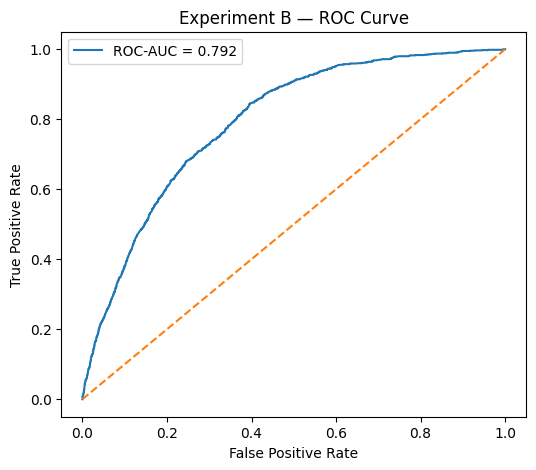

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, test_prob)
test_roc_auc = roc_auc_score(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Experiment B — ROC Curve")
plt.legend()
plt.show()

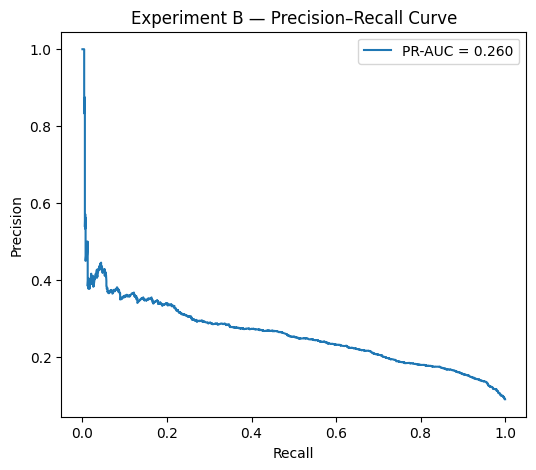

In [43]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, test_prob)
test_pr_auc = average_precision_score(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {test_pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Experiment B — Precision–Recall Curve")
plt.legend()
plt.show()

In [44]:
experiment_b_results = pd.DataFrame([{
    "experiment": "B_Preliminary",
    "model": "Logistic Regression",
    "threshold": FINAL_THRESHOLD,
    "accuracy": accuracy_score(y_test, final_test_pred),
    "precision": precision_score(y_test, final_test_pred),
    "recall": recall_score(y_test, final_test_pred),
    "f1": f1_score(y_test, final_test_pred),
    "roc_auc": roc_auc_score(y_test, test_prob),
    "pr_auc": average_precision_score(y_test, test_prob),
    "train_log_loss": train_log_loss,
    "validation_log_loss": val_log_loss,
    "test_log_loss": test_log_loss
}])

print(experiment_b_results.round(4).to_string(index=False))

   experiment               model  threshold  accuracy  precision  recall     f1  roc_auc  pr_auc  train_log_loss  validation_log_loss  test_log_loss
B_Preliminary Logistic Regression      0.635    0.7856     0.2332   0.598 0.3355   0.7918  0.2595          0.5567               0.5612         0.5569


In [45]:
RESULTS_FILE = "experiment_B_results.csv"

experiment_b_results.to_csv(
    RESULTS_FILE,
    index=False
)

print(f"Results saved to {RESULTS_FILE}")

Results saved to experiment_B_results.csv


## Experiment B. Interpretation

I looked at the feature set and it achieved a test ROC-AUC of 0.792 and a PR-AUC of 0.260. After selecting the classification threshold with the validation set, the final test accuracy reached 0.786 while the precision was 0.233 the recall was 0.598 and the F1-score was 0.336.

Compared with the baseline experiment this feature set produced accuracy, higher precision, a higher F1 score, a higher ROC-AUC and a higher PR-AUC yet it produced a lower recall. This indicates a precision-recall trade-off rather than a uniformly better model.

The final test confusion matrix contained 2,358 positives and 482 false negatives. I saw that false positives were concentrated in age, BMI, education and income groups. These are patterns in model errors and do not establish causal relationships.

1/5th to 1/4th of the false negatives and false positives were within 0.05 of the selected threshold while the remaining errors were farther, from the decision boundary. I also noted that some observations were misclassified with high confidence showing that the errors were not entirely caused by borderline cases.

The training, validation and test log-loss values were similar providing no indication of severe overfitting based on this metric alone.

## Experiment A vs Experiment B

The two experiments use the same CCHS 2022 modelling population, train/validation/test split, Logistic Regression configuration, and evaluation procedure. The main controlled difference is the feature set.

Experiment A uses the original baseline feature set, while Experiment B uses the preliminary feature set identified during the dataset exploration stage.

In [46]:
comparison = pd.DataFrame([
    {
        "Experiment": "A_Baseline",
        "Features": 11,
        "Threshold": 0.570,
        "Accuracy": 0.721,
        "Precision": 0.199,
        "Recall": 0.690,
        "F1": 0.309,
        "ROC-AUC": 0.782,
        "PR-AUC": 0.247
    },
    {
        "Experiment": "B_Preliminary",
        "Features": 11,
        "Threshold": 0.635,
        "Accuracy": 0.786,
        "Precision": 0.233,
        "Recall": 0.598,
        "F1": 0.336,
        "ROC-AUC": 0.792,
        "PR-AUC": 0.260
    }
])

print(comparison.to_string(index=False))

   Experiment  Features  Threshold  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
   A_Baseline        11      0.570     0.721      0.199   0.690 0.309    0.782   0.247
B_Preliminary        11      0.635     0.786      0.233   0.598 0.336    0.792   0.260
